<u><b><h1 style="text-align:center; line-height:25px; color:#000000; background:#EFEFEF; border: 1px solid #FF6B6B ; padding:20px;">Extracting Prevalent Topics from Citizens Complaints using NLP</h1></b></u>
<u><h2 style="text-align:center">2. Preprocessing step</h2></u>
**Course:** DLBDSEDA02 – Project: Data Analysis  
**Tools**: Python, pandas, NLTK, scikit-learn, gensim, Matplotlib  
**Dataset:** <a href="https://www.kaggle.com/datasets/xjoury/customer-complaints-sentiment-and-priority-dataset">Customer Complaints Sentiment and Priority Dataset</a>  
**<a href="https://github.com/davidlupau/complaint-topic-modeling">GitHub repository</a>**

<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Setup & Imports</h2></b>

In [1]:
import pandas as pd
import sys
from pathlib import Path

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src").is_dir()
)
sys.path.append(str(PROJECT_ROOT / "src"))

from utils import load_dataset
from preprocessing import (
    select_columns,
    clean_text,
    tokenize_and_remove_stopwords,
    lemmatize_tokens,
    preprocess_corpus,
    save_processed_data,
)

print("Import successful")

Import successful


### Loading the dataset

In [2]:
df = load_dataset("Customer_Complaints_Sentiment_and_Priority_Dataset.csv")


Loading dataset...

Successfully loaded Customer_Complaints_Sentiment_and_Priority_Dataset.csv 



<b><h2 style="padding: 10px; border-left: 3px solid #FF6B6B;">Preprocessing Pipeline</h2></b>

The EDA notebook identified concrete cleaning needs: no missing or duplicate narratives (no dropping needed there), the `XXXX` redaction token dominating the raw vocabulary (12,956+ occurrences), heavy stopword presence, inconsistent casing, and complaint lengths ranging from 2 to 2,618 words (median 155). The steps below, each backed by a function in `src/preprocessing.py`, address these findings one at a time.

### Column selection

Per the project's conception phase, `Sentiment` and `Priority` are structured metadata excluded from topic extraction, they're not free text and would add nothing to an unsupervised topic model. `Product` is kept, but only as an external validation signal to check later whether discovered topics align with product categories; it is never used as model input.

In [3]:
selected_df = select_columns(df)
selected_df.head()

Selected columns: ['Consumer_complaint', 'Product'] (1750 rows)


,Consumer_complaint,Product
0,I had overdraft protection with Regions Bank i...,Checking or savings account or service
1,"I am the sole, legal representative of my dece...",Checking or savings account or service
2,This bank has consistantly manipulated my dire...,Checking or savings account or service
3,I enrolled in a Citibank checking account in X...,Checking or savings account or service
4,TIAA-XXXX has not responded to multiple reque...,Checking or savings account or service


`select_columns()` kept only `Consumer_complaint` and `Product`, dropping `Sentiment` and `Priority` as planned. The resulting frame still has all 1,750 rows, just 2 columns instead of 4.

---

### Text cleaning

The EDA's raw token frequency check found the `XXXX` redaction placeholder occurring 12,956+ times (plus more as `XXXX,`, confirming punctuation stays attached to tokens), and the manual sample read surfaced inconsistent casing, embedded currency values like `{$22000.00}`, and stray punctuation. `clean_text()` lowercases the narrative, strips `XXXX` tokens, removes punctuation and digits, and collapses the resulting extra whitespace.

In [4]:
sample_raw = selected_df["Consumer_complaint"].iloc[298]
sample_cleaned = clean_text(sample_raw)

print("RAW:\n")
print(sample_raw)
print("\nCLEANED:\n")
print(sample_cleaned)

RAW:

Equifax fails to remove the XXXX XXXX XXXX XXXX account. Equifax reports incorrectly that this account has a balance {$22000.00}. Equifax reports incorrectly that this is an XXXX account. Equifax reports incorrectly this account 's Date of First Delinquency. Equifax continues to report inaccurate information on my credit file which lowers my credit score. This causes me the inability to obtain credit and lowers my standards of living and causes me to languish and suffer.

CLEANED:

equifax fails to remove the account equifax reports incorrectly that this account has a balance equifax reports incorrectly that this is an account equifax reports incorrectly this account date of first delinquency equifax continues to report inaccurate information on my credit file which lowers my credit score this causes me the inability to obtain credit and lowers my standards of living and causes me to languish and suffer


The cleaned version is fully lowercase, the four `XXXX` redaction tokens are gone, the `{$22000.00}` currency artifact has lost its punctuation and digits (leaving a stray "account has a balance" phrase, digits removed), and sentence-ending periods and apostrophes have been stripped, with whitespace collapsed to single spaces throughout.

---

### Tokenization & stopword removal

The EDA's raw token frequency check showed the vocabulary dominated by common English stopwords ("the", "to", "and", "I", "a"...), which carry no topical meaning and would otherwise drown out the terms a topic model should surface. `tokenize_and_remove_stopwords()` runs NLTK's `word_tokenize` on the cleaned text and drops any token found in NLTK's standard English stopword list.

In [5]:
sample_tokens = tokenize_and_remove_stopwords(sample_cleaned)

print(f"Tokens before stopword removal: {len(sample_cleaned.split())}")
print(f"Tokens after stopword removal: {len(sample_tokens)}\n")
print(sample_tokens)

Tokens before stopword removal: 68
Tokens after stopword removal: 40

['equifax', 'fails', 'remove', 'account', 'equifax', 'reports', 'incorrectly', 'account', 'balance', 'equifax', 'reports', 'incorrectly', 'account', 'equifax', 'reports', 'incorrectly', 'account', 'date', 'first', 'delinquency', 'equifax', 'continues', 'report', 'inaccurate', 'information', 'credit', 'file', 'lowers', 'credit', 'score', 'causes', 'inability', 'obtain', 'credit', 'lowers', 'standards', 'living', 'causes', 'languish', 'suffer']


Stopwords such as "the", "this", "that", "has", "is" and "an" have been removed, leaving only content-bearing tokens like "equifax", "fails", "remove", "account" and "balance" — the words that actually carry topical signal.

---

### Lemmatization

Inflected forms like "reports"/"report" or "lowers"/"lower" are the same underlying concept, but a topic model would otherwise treat them as distinct vocabulary terms, splitting their frequency and diluting the signal each concept carries. `lemmatize_tokens()` reduces each token to its base form with NLTK's `WordNetLemmatizer`, using the default noun part of speech for simplicity.

In [6]:
sample_lemmas = lemmatize_tokens(sample_tokens)

changed = [(t, l) for t, l in zip(sample_tokens, sample_lemmas) if t != l]
print(f"Tokens changed by lemmatization: {len(changed)} / {len(sample_tokens)}")
print(changed)

Tokens changed by lemmatization: 8 / 40
[('reports', 'report'), ('reports', 'report'), ('reports', 'report'), ('lowers', 'lower'), ('causes', 'cause'), ('lowers', 'lower'), ('standards', 'standard'), ('causes', 'cause')]


8 of the 40 tokens changed form: plurals and verb conjugations like "reports" → "report", "lowers" → "lower", "causes" → "cause" and "standards" → "standard" were reduced to their base form, so these variants will now be counted as the same term during vectorization.

---

### Full pipeline & minimum-length filtering

The EDA's length distribution check found complaints ranging from 2 to 2,618 words (median 155), and flagged the 2-word minimum as a concern: a complaint that short carries almost no topic signal, and after stopword removal and cleaning it may end up nearly empty. `preprocess_corpus()` runs `select_columns`, `clean_text`, `tokenize_and_remove_stopwords` and `lemmatize_tokens` over the whole dataset, rejoins the lemmas into a `cleaned_complaint` column, and drops any row whose cleaned token count falls below `min_tokens` (default 5).

In [7]:
processed_df = preprocess_corpus(df, min_tokens=5)
processed_df.head()


Running preprocessing pipeline...

Selected columns: ['Consumer_complaint', 'Product'] (1750 rows)


Cleaned and lemmatized 1750 narratives
Dropped 5 rows with fewer than 5 cleaned tokens
Resulting row count: 1745


,Consumer_complaint,Product,cleaned_complaint
0,I had overdraft protection with Regions Bank i...,Checking or savings account or service,overdraft protection region bank alabama check...
1,"I am the sole, legal representative of my dece...",Checking or savings account or service,sole legal representative deceased mother esta...
2,This bank has consistantly manipulated my dire...,Checking or savings account or service,bank consistantly manipulated direct deposit o...
3,I enrolled in a Citibank checking account in X...,Checking or savings account or service,enrolled citibank checking account using promo...
4,TIAA-XXXX has not responded to multiple reque...,Checking or savings account or service,tiaa responded multiple request trusteetotrust...


Out of the original 1,750 complaints, 5 were dropped for falling below the 5-token minimum after cleaning, leaving 1,745 rows. This confirms the EDA's concern about very short complaints was limited in scope — only a handful of documents were too thin to carry topic signal once cleaned.

---

### Before/after: a full complaint end-to-end

To make the overall transformation concrete, here is one complaint as it entered the pipeline versus how it looks after cleaning, stopword removal and lemmatization:

In [8]:
example = processed_df.iloc[0]

print("RAW:\n")
print(example["Consumer_complaint"])
print("\nCLEANED:\n")
print(example["cleaned_complaint"])

RAW:

I had overdraft protection with Regions Bank in XXXX, Alabama on my checking account. However, instead of waiting to get the overdraft from my Social Security Check that come in every month. They took the overdraft from my grandchildren savings so it would n't net interest. So, I took my grandchildren money out of Regions Bank. They retaliated by closing both of my checking accounts without notice. Therefore, I could n't receive my Social Security check for the entire month of XX/XX/XXXX with put a great hardship on my me and my family.

CLEANED:

overdraft protection region bank alabama checking account however instead waiting get overdraft social security check come every month took overdraft grandchild saving wouldnt net interest took grandchild money region bank retaliated closing checking account without notice therefore couldnt receive social security check entire month put great hardship family


The raw narrative mixes casing, punctuation and an `XXXX` redaction of the location ("Regions Bank in XXXX, Alabama"). In `cleaned_complaint`, the text is lowercase, `XXXX` is gone, punctuation and contractions have collapsed ("wouldn't" → "would nt"), and stopwords like "with", "in", "on", "from" and "the" have been removed — leaving a dense string of the terms ("overdraft", "region", "bank", "grandchild", "saving", "retaliated") that actually describe the complaint.

---

### Saving the processed corpus

The cleaned corpus is persisted to `data/processed/` so the vectorization and topic modeling notebooks can load it directly without re-running preprocessing each time.

In [9]:
save_processed_data(processed_df, "complaints_clean.csv")

Saved processed data to: /Users/davidlupau/Documents/Filen/_IU/6th semester/32. Project Data Analysis/complaint-topic-modeling/data/processed/complaints_clean.csv


---

### Post-cleaning vocabulary check

A single before/after example shows the transformation is working, but it can't reveal what's happening across the whole corpus. Before moving to vectorization, we reuse `check_frequent_tokens()` from the EDA module — this time on `cleaned_complaint` instead of the raw narrative — to verify the cleaning pipeline actually produced a usable vocabulary, catch any leftover noise (stray artifacts, mis-tokenized fragments) that survived cleaning, and flag any ubiquitous domain terms — words appearing in nearly every complaint regardless of topic — that generic stopword removal wouldn't have caught. This matters because such terms would otherwise dominate raw counts and would need to be considered when choosing between Bag-of-Words and TF-IDF in the next notebook (TF-IDF would naturally downweight them; BoW would not).


=== Top 30 tokens in 'cleaned_complaint' ===

token
account        3203
credit         2007
payment        1914
loan           1506
bank           1504
would          1379
time           1193
told           1095
card           1038
money           997
received        949
company         925
day             919
called          883
call            871
report          847
information     837
back            761
month           711
never           705
amount          701
sent            698
pay             693
debt            687
letter          686
number          686
fee             678
get             672
mortgage        667
phone           659

Saved plot to: /Users/davidlupau/Documents/Filen/_IU/6th semester/32. Project Data Analysis/complaint-topic-modeling/analysis_output/top_cleaned_tokens.png


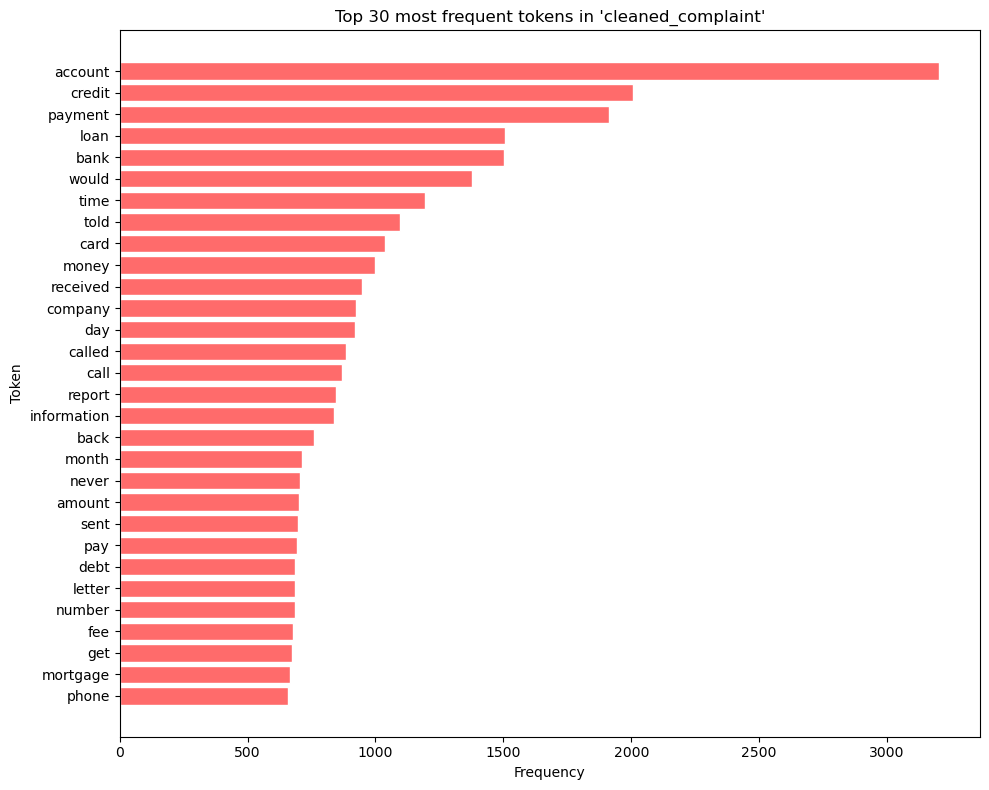

In [10]:
import matplotlib.pyplot as plt
from data_exploration import check_frequent_tokens

top_cleaned_tokens = check_frequent_tokens(
    processed_df, column="cleaned_complaint", top_n=30, filename="top_cleaned_tokens.png"
)
plt.show()

**Top terms observed:** The vocabulary is dominated by genuine, domain-relevant content words — `account`, `credit`, `payment`, `loan`, `bank`, `card`, `debt`, `fee`, `mortgage` — confirming the cleaning pipeline produced a coherent vocabulary tied to financial complaints, not noise.

**Ubiquitous terms:** `account` leads by a wide margin (3,203 — roughly 60% ahead of the next term), and plausibly appears across nearly every Product category (checking accounts, credit card accounts, loan accounts, mortgage accounts), making it a weak discriminator between topics on its own. `credit`, `payment` and `bank` show a similar pattern to a lesser degree. These are good candidates for TF-IDF's inverse-document-frequency weighting to naturally downweight; this is a concrete point of comparison to revisit when contrasting BoW vs. TF-IDF in `03_vectorization`.

**Leftover artifacts:** none of concern. The vocabulary contains only genuine content words, with no stray fragments or mis-tokenized pieces.